# Homogeneous Square

In [1]:
# Change start method form 'fork' for clusters
import multiprocessing
multiprocessing.set_start_method('forkserver')

import matplotlib.pyplot as plt
import numpy as np
import torch as tn
from igakit import cad

from ttnte.xs.benchmarks import Server
from ttnte.iga import IGAMesh
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import LinearOperator, fixed_source
from ttnte.cad import Patch
from ttnte.sources import IsotropicInternalSource
from mpl_toolkits.axes_grid1 import make_axes_locatable

tn.set_default_dtype(tn.float64)

## Define Cross Section Library and IGA Mesh

In [2]:
# Discretization
num_ordinates = 4096

# Get XS data
total = 1  # 1/cm
scattering_ratio = 0.9
xs_server = Server(
    {
        "Material": {
            "total": np.array([total]),
            "scatter_gtg": np.array([[[total * scattering_ratio]]]),
        }
    }
)

In [3]:
# Create NURBS geometry
length = 10 # cm
points = np.array(
    [
        [-length / 2, -length / 2, 0],
        [length / 2, -length / 2, 0],
        [-length / 2, length / 2, 0],
        [length / 2, length / 2, 0],
    ]
).reshape((2, 2, -1))
patch = Patch(cad.bilinear(points), "Material")

# Add uniform source of 1/cm to patch
source = IsotropicInternalSource(np.ones((1, *patch.shape)))
patch.set_source(source)

# Create mesh
mesh = IGAMesh(max_processes=32)
mesh.add_patch(patch)

# Refine mesh resolution
mesh.refine(factor=13, degree=3)

# Connect patches
mesh.connect()

# Finalize mesh
mesh.finalize()
mesh

IGAMesh(id=0, name=None, num_patches=1, reflective_boundaries=False)
  -> Patch(material=Material, source=<ttnte.sources.isotropic_internal_source.IsotropicInternalSource object at 0x7f77334e2a50>, id=0, name=None, shape=(16, 16), backend=geomdl)

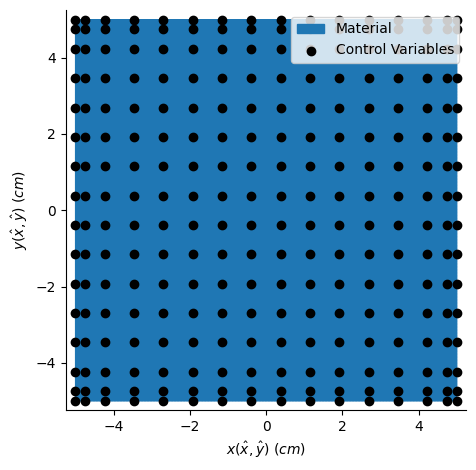

In [4]:
# Plot final mesh
ax = mesh.plot()
plt.tight_layout()
plt.savefig("./figs/square.png", dpi=300)
plt.show()

## Assemble Matrix and TT Operators

In [5]:
# Create operators in COO format
assembler = MatrixAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
mats = assembler.build()

# Save TT information
assembler.save_info("./coo_info.csv")

## Create operators in COO format
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
tts = assembler.build(use_tt=False, eps=1e-10, q=False)

# Save TT information
assembler.save_info("./tt_info.csv")

Running MatrixAssembler.build()
Discretization: N = 4096, G = 1, P = 1, A = 16, B = 16
Operators: H, S, q, B_out
---------------------------------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 41.29 s)
Step            Ranks                     Compression
H               1048576,1048576              8947.85
S               1,256,256                       1.64
q               1048576                         1.00
B_out           1048576,1048576            449640.63
Running TTAssembler.build()
Discretization: N = 4096, G = 1, P = 1, A = 16, B = 16
Operators: H, S, B_out
---------------------------------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 5.64 s)
Step            Ranks                     Compression
H               3,3,3,2                   53561556.30
S               1,1,1,1                   426829048.05
B_out           3,4,4,3                   33768784.64


## Solve

In [6]:
# Run fixed source calculation
psi = fixed_source(
    T=LinearOperator([tts.H, mats.B_out, -tts.S], N=assembler.N, M=assembler.M),
    q=mats.q,
    device=0,
    max_iters=50,
    tol=1e-8,
    restarts=250,
)

# Save solution
mesh.save(path="mesh.hdf5", solution=psi.unsqueeze(3))

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy()

GMRES Finished
Elapsed Time: 6.751521348953247


## Plotting and Comparison to OpenMC

In [7]:
leakage_frac_openmc = [0.420974, 2.22902e-05]
phi_mc = np.load("./openmc/data/mesh_flux.npy")

# Ensure OpenMC solution is normalized
phi_mc /= np.linalg.norm(phi_mc.flatten(), 2)

leakage = assembler.outward_current(psi)
production = assembler.total_production()
leakage_frac = round(float(leakage / production), 5)
print("Leakage fraction error: {} -/+ {}".format(
    leakage_frac - leakage_frac_openmc[0], leakage_frac_openmc[1])
)

Leakage fraction error: -4.000000000004e-06 -/+ 2.22902e-05


<Figure size 640x480 with 0 Axes>

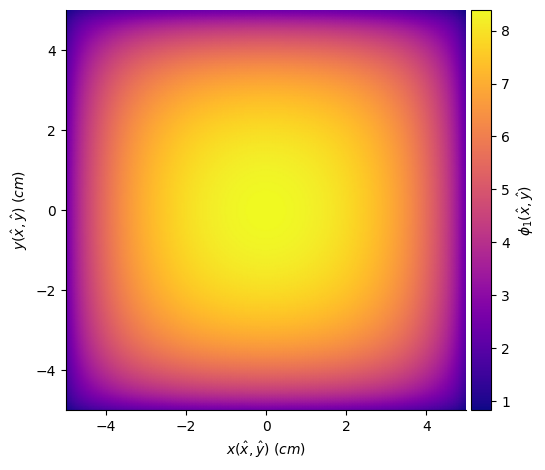

In [8]:
# Map rectangular mesh
pids, coords = mesh.map_regular_mesh(shape=phi_mc.shape[1:], N=(5, 5))

# Iterate through groups and plot
phi_avg = np.zeros(phi_mc.shape)
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Calculate regular mesh
    phi_avg[g,] = mesh.regular_mesh(pids, coords)

    # Plot
    plt.clf()
    ax, cbar = mesh.plot(plot_ctrlpts=False)
    cbar.set_label(f"$\\phi_{g + 1}" + "(\\hat{x}, \\hat{y})$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_{g + 1}.png", dpi=300)
    plt.show()

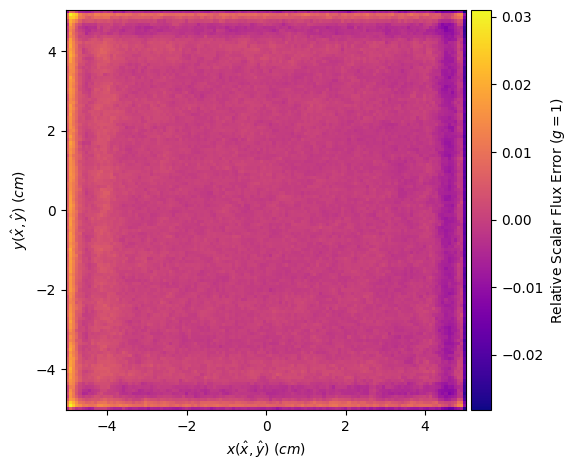

Scalar flux Relative L2-error (g = 1): 0.0019309956122084758
Total scalar flux Relative L2-error: 0.0019309956122084758


In [9]:
# Normalize average
phi_avg /= np.linalg.norm(phi_avg.flatten(), 2)

# Regular mesh
X, Y = np.meshgrid(
    np.linspace(-5, 5, phi_mc.shape[1]),
    np.linspace(-5, 5, phi_mc.shape[2]),
)

for g in range(xs_server.num_groups):    
    # Plot relative error
    plt.clf()
    ax = plt.gca()
    cmesh = ax.pcolormesh(
        X, Y, (phi_mc[g,] - phi_avg[g,]) / phi_mc[g,], cmap="plasma"
    )
    divider = make_axes_locatable(ax)

    plt.colorbar(
        cmesh,
        cax=divider.append_axes("right", size="5%", pad=0.05),
        label=f"Relative Scalar Flux Error ($g = {g + 1}$)",
    )
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x(\hat{x}, \hat{y})~(cm)$")
    ax.set_ylabel(r"$y(\hat{x}, \hat{y})~(cm)$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi{g + 1}_error.png", dpi=300)
    plt.show()
    
    # Calculate groups L2-error
    print(
        "Scalar flux Relative L2-error (g = {}): {}".format(
            g + 1, 
            np.linalg.norm(
                (phi_avg[g,] - phi_mc[g,]).flatten(), 2
            ) / np.linalg.norm(phi_mc[g,].flatten(), 2)
        )
    )
print(
    "Total scalar flux Relative L2-error: {}".format(
        np.linalg.norm(
            (phi_avg - phi_mc).flatten(), 2
        ) / np.linalg.norm(phi_mc.flatten(), 2)
    )
)